# Spotify Final Project - Group 11

### Karen's Code

In [3]:
import numpy                 as np
import pandas                as pd
import matplotlib.pyplot     as plt
import seaborn               as sns
import sklearn.metrics       as Metrics

import folium  #needed for interactive map
from folium.plugins import HeatMap
from matplotlib.patches import Patch

from   collections           import Counter
from   sklearn               import preprocessing
from   datetime              import datetime
from   collections           import Counter
from   math                  import exp
from   sklearn.linear_model  import LinearRegression as LinReg
from   sklearn.metrics       import mean_absolute_error
from   sklearn.metrics       import median_absolute_error
from   sklearn.metrics       import r2_score
import statsmodels
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy 
import statsmodels.formula.api as smf


%matplotlib inline
sns.set()


## Cleaning Process

In [5]:
df = pd.read_csv('dataset.csv')
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [6]:
df.shape

(114000, 21)

In [7]:
#Dataframe has extra 'unnamed' column, dropping
df = df.drop(df.columns[0], axis=1)
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [8]:
#There are some duplicated tracks that appear in the dataframe, we must remove these first

duplicate_track_ids = df['track_id'].value_counts()
duplicate_track_ids = duplicate_track_ids[duplicate_track_ids > 1]
duplicate_track_ids

track_id
6S3JlDAGk3uu3NtZbPnuhS    9
2Ey6v4Sekh3Z0RUSISRosD    8
2kkvB3RNRzwjFdGhaUA0tz    8
5ZsAhuQ24mWHiduaxJqnhW    7
08kTa3SL9sV6Iy8KLKtGql    7
                         ..
2a05MFdR1vtm8QVKFs1SGn    2
2BJdsyqP0IfOt0GR2a6zJl    2
7oyFihJppZYPP7o0NfoHnZ    2
0oz7Ia8lnWttkXi2TBc1Rd    2
1cbCEtcGU25HvwMrZDPqJy    2
Name: count, Length: 16641, dtype: int64

In [9]:
df = df.drop_duplicates(subset='track_id', keep='first')

In [10]:
#Checking for duplicates again
duplicate_track_ids = df['track_id'].value_counts()
duplicate_track_ids = duplicate_track_ids[duplicate_track_ids > 1]
duplicate_track_ids

Series([], Name: count, dtype: int64)

In [11]:
df.shape

(89741, 20)

In [12]:
df[df.isna().any(axis=1)]
df = df.fillna('unknown')

#NaN values, only in one row for 'artist, album_name and track_name'
#No way to fill in data, but useful, fill in with 'unknown' str

In [13]:
df.dtypes

track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

**string cleaning**

In [15]:
#ensuring all data entries in these columns are of string type
df['track_id'] = df['track_id'].astype(str)
df['artists'] = df['artists'].astype(str)
df['album_name'] = df['album_name'].astype(str)
df['track_name'] = df['track_name'].astype(str)
df['track_genre'] = df['track_genre'].astype(str)

In [16]:
#string cleaning methods - cleaning any unintentional duplicates
#exception is track_id > those cannot be changed (upper/lowercase - messed up id)
#changing any m-dashes to hyphens for consistency
df['artists'] = (df['artists'].str.replace("–", "-").str.title().str.strip()
                 .str.replace("'S", "'s", regex=False)
                 .str.replace("'T", "'t", regex=False) #ensures letters in contractions are not capitalized
                 .str.replace("'V", "'v", regex=False)
                 .str.replace("'L", "'l", regex=False)
                 .str.replace("'M", "'m", regex=False)
                 .str.replace("'R", "'r", regex=False)
                )
df['album_name'] = (df['album_name'].str.replace("–", "-").str.title().str.strip()
                    .str.replace("'S", "'s", regex=False)
                    .str.replace("'T", "'t", regex=False)
                    .str.replace("'V", "'v", regex=False)
                    .str.replace("'L", "'l", regex=False)
                    .str.replace("'M", "'m", regex=False)
                    .str.replace("'R", "'r", regex=False)
                   )
df['track_name'] = (df['track_name'].str.replace("–", "-").str.title().str.strip()
                    .str.replace("'S", "'s", regex=False)
                    .str.replace("'T", "'t", regex=False)
                    .str.replace("'V", "'v", regex=False)
                    .str.replace("'L", "'l", regex=False)
                    .str.replace("'M", "'m", regex=False)
                    .str.replace("'R", "'r", regex=False)
                   )

df['track_genre'] = (df['track_genre'].str.replace("–", "-").str.title().str.strip()
                     .str.replace("'S", "'s", regex=False)
                     .str.replace("'T", "'t", regex=False)
                     .str.replace("'V", "'v", regex=False)
                     .str.replace("'L", "'l", regex=False)
                     .str.replace("'M", "'m", regex=False)
                     .str.replace("'R", "'r", regex=False)
                    )

df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,Acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,Acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;Zayn,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,Acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,Acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,Acoustic


**Creating Variables**

In [18]:
#Looking for duplicate songs - i.e songs that are posted as a single and album
#Groups df by all columns except track ID, album name and popularity, since documentation says they are the same except for ID
#Lambda function looks for groups greater than 1, i.e 2+ rows are the same - i.e duplicate song
duplicate_songs = df.copy()
duplicate_songs = duplicate_songs.groupby([column for column in duplicate_songs.columns if column not in ['track_id', 'album_name', 'popularity', 'track_type']]).filter(lambda x: len(x) > 1)
duplicate_songs.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
6,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,74,229400,False,0.407,0.147,2,-8.822,1,0.0355,0.857,0.000003,0.0913,0.0765,141.284,3,Acoustic
7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,False,0.703,0.444,11,-9.331,1,0.0417,0.559,0.000000,0.0973,0.7120,150.960,4,Acoustic
8,0IktbUcnAGrvD03AWnz3Q8,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,74,189613,False,0.625,0.414,0,-8.700,1,0.0369,0.294,0.000000,0.1510,0.6690,130.088,4,Acoustic
10,4mzP5mHkRvGxdhdGdAH7EJ,Zack Tabudlo,Episode,Give Me Your Forever,74,244800,False,0.627,0.363,8,-8.127,1,0.0291,0.279,0.000000,0.0928,0.3010,99.905,4,Acoustic
18,2qLMf6TuEC3ruGJg4SMMN6,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,68,189613,False,0.625,0.414,0,-8.700,1,0.0369,0.294,0.000000,0.1510,0.6690,130.088,4,Acoustic


In [19]:
#Separate the 'duplicate song' dataframe into the 'singles' duplicates and 'album duplicate' 
#singles will have the same album name and track name

single_duplicates = duplicate_songs[duplicate_songs['album_name'] == duplicate_songs['track_name']]
album_duplicates = duplicate_songs[duplicate_songs['album_name'] != duplicate_songs['track_name']]

In [20]:
#merge these dataframes matches songs to album they are also in

true_duplicates = pd.merge(single_duplicates, album_duplicates, 
                        on=['track_name', 'artists'], 
                        how='inner', 
                        suffixes=('_singles', '_album'))

true_duplicates = true_duplicates[['track_id_singles', 'artists', 'album_name_singles', 
                                   'track_name','popularity_singles', 'track_id_album','album_name_album', 
                                   'popularity_album']]

**In our midterm report, we mentioned we would take the average of the popularity of the duplicate songs (tracks posted as a single and album)**
- We did not anticipate playlists to be in the dataset
- For the project, we will be considering playlists as albums
- For many playlists, the popularity of songs is 0. Thus taking the average of the popularities would be inaccurate.
- We will no longer be taking the average and only consider songs that are a single or in an album

In [22]:
#Variable to indicate songs that are singles and songs that are in albums
df['single'] = df['track_name'] == df['album_name']
df['track_type'] = df['single'].apply(lambda x: 'Single' if x else 'Album')
df = df.drop('single', axis = 1)

In [23]:
#Creating popular_track variable
#HP > 80, N < 50
#50<= P < 80

def popular_tracks(popularity):
    if popularity >= 80:
        return 'HP'
    elif popularity >= 50:
        return 'P'
    else:
        return 'N'

df['popular_track'] = df['popularity'].apply(popular_tracks)

In [24]:
#creates variables num_popular and num_high_popular
# counts the number of (highly) popular songs in an album

num_popular = df.groupby('album_name')['popular_track'].apply(lambda x: (x=='P').sum()).reset_index(name = 'num_popular')
num_high_popular = df.groupby('album_name')['popular_track'].apply(lambda x: (x=='HP').sum()).reset_index(name = 'num_high_popular')

df = df.merge(num_popular, on ='album_name', how = 'left').merge(num_high_popular, on ='album_name', how = 'left')

In [25]:
df['num_artist'] = df['artists'].apply(lambda x: len(x.split(';')))

In [26]:
df['collab'] = df['num_artist'].apply(lambda x: 'C' if x > 1 else 'S')

In [27]:
album_popularity = df.groupby('album_name')['popularity'].mean().reset_index()
album_popularity = album_popularity.rename(columns={'popularity': 'album_avg_popularity'})
df = df.merge(album_popularity, on='album_name', how='left')
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,tempo,time_signature,track_genre,track_type,popular_track,num_popular,num_high_popular,num_artist,collab,album_avg_popularity
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,87.917,4,Acoustic,Single,P,1,0,1,S,73.0
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,77.489,4,Acoustic,Album,P,1,0,1,S,55.0
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;Zayn,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,76.332,4,Acoustic,Single,P,1,0,2,C,57.0
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,181.740,3,Acoustic,Album,P,1,0,1,S,71.0
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,119.949,4,Acoustic,Single,HP,1,1,1,S,39.0


----------------------

## Coding

I will be working on the coding for three subquestions

For the first topic: Impact of Popular Songs
- **Is this trend consistent across different genres of music?**
- **How does the popularity of singles impact the song's popularity in the album? Specifically for 'duplicate songs' (songs that appear in an album and as a single)**

For the second topic: Changes in Musical Attributes
- **Do musical attributes change more when artists from different genres collaborate?**

  

## First Topic

**First SubQuestion**

First, we want to witness if the presence of a popular song in an album increases the listener engagement of other songs in an album. We want to discover whether or not there is a relationship. 

In [34]:
#Add a flag to df for albums that contain a highly popular/ popular song
df['pop_flag'] = df.groupby('album_name')['popular_track'].transform(lambda x: x.isin(['P', 'HP']).any())
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,time_signature,track_genre,track_type,popular_track,num_popular,num_high_popular,num_artist,collab,album_avg_popularity,pop_flag
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,4,Acoustic,Single,P,1,0,1,S,73.0,True
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,4,Acoustic,Album,P,1,0,1,S,55.0,True
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;Zayn,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,4,Acoustic,Single,P,1,0,2,C,57.0,True
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,3,Acoustic,Album,P,1,0,1,S,71.0,True
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,4,Acoustic,Single,HP,1,1,1,S,39.0,True


In [35]:
#Find all albums with popular/highly popular songs 
popular_albums = df[df['pop_flag'] == True]

#From these albums with popular/highly popular songs, remove them and calculate popularity for the rest of album
filtered_popular_albums = popular_albums[~popular_albums['popular_track'].isin(['HP','P'])]
average_popularity_score = filtered_popular_albums.groupby('album_name')['popularity'].mean().reset_index()

#Albums without popular songs
nonp_albums = df[df['pop_flag'] == False]
average_popularity_nonp = nonp_albums.groupby('album_name')['popularity'].mean().reset_index()

In [36]:
#Adding a column to each df to differentiate albums after combining df again to visualize
average_popularity_score['group'] = 'Includes Popular Song'
average_popularity_nonp['group'] = 'No Popular Song'
combined_alb = pd.concat([average_popularity_score, average_popularity_nonp])
combined_alb.head()

,album_name,popularity,group
0,"""Attack On Titan"" Season 3 Original Soundtrack",46.000000,Includes Popular Song
1,"""Fairy Tail"" Original Soundtrack Vol.1",47.333333,Includes Popular Song
2,#1 Record (Remastered),38.000000,Includes Popular Song
3,#Acoustic,48.000000,Includes Popular Song
4,#Covers,41.400000,Includes Popular Song


In [37]:
combined_alb.tail()

,album_name,popularity,group
31649,黎明音樂大全 101,20.0,No Popular Song
31650,黎瑞恩 湯寶如 劉小慧音樂大全101,19.0,No Popular Song
31651,黑色領帶,20.0,No Popular Song
31652,黒い羊 (Special Edition),25.0,No Popular Song
31653,齊唱金曲管弦夜,23.0,No Popular Song


In [38]:
#Trying to plot again based on only highly popular

df['hpop_flag'] = df.groupby('album_name')['popular_track'].transform(lambda x: x.isin(['HP']).any())

#Find all albums with highly popular songs 
hpopular_albums = df[df['hpop_flag'] == True]

#From these albums with popular/highly popular songs, remove them and calculate popularity for the rest of album
filtered_hpopular_albums = hpopular_albums[~hpopular_albums['popular_track'].isin(['HP'])]
average_hpopularity_score = filtered_hpopular_albums.groupby('album_name')['popularity'].mean().reset_index()

#Albums without popular songs
nonhp_albums = df[df['pop_flag'] == False]
average_popularity_nonhp = nonhp_albums.groupby('album_name')['popularity'].mean().reset_index()

In [39]:
#Adding a column to each df to differentiate albums after combining df again to visualize
average_hpopularity_score['group'] = 'Includes Highly Popular Song'
average_popularity_nonhp['group'] = 'No Highly Popular Song'
combined_halb = pd.concat([average_hpopularity_score,average_popularity_nonhp])
combined_halb.head()

,album_name,popularity,group
0,#3 Deluxe Version,60.000000,Includes Highly Popular Song
1,(Un)Commentary,61.666667,Includes Highly Popular Song
2,17,68.200000,Includes Highly Popular Song
3,18 Months,66.142857,Includes Highly Popular Song
4,1989,51.000000,Includes Highly Popular Song


In [40]:
combined_halb.tail()

,album_name,popularity,group
31649,黎明音樂大全 101,20.0,No Highly Popular Song
31650,黎瑞恩 湯寶如 劉小慧音樂大全101,19.0,No Highly Popular Song
31651,黑色領帶,20.0,No Highly Popular Song
31652,黒い羊 (Special Edition),25.0,No Highly Popular Song
31653,齊唱金曲管弦夜,23.0,No Highly Popular Song


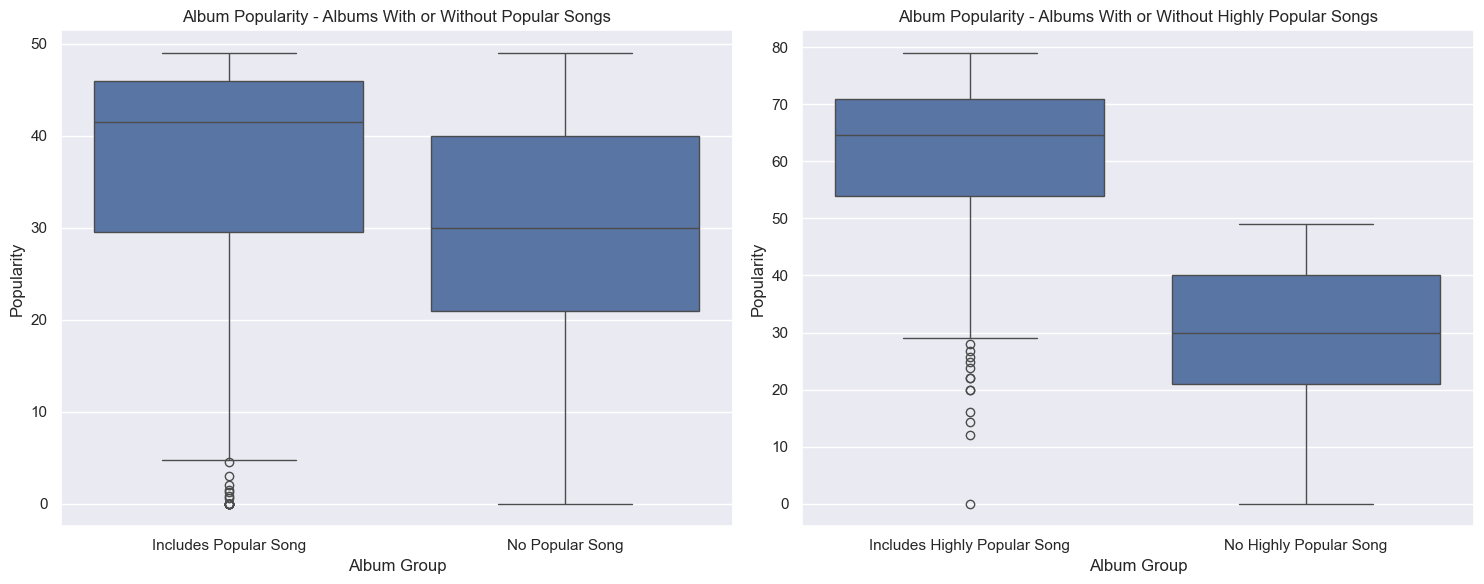

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(x='group', y='popularity', data=combined_alb, ax=axes[0])
axes[0].set_title('Album Popularity - Albums With or Without Popular Songs')
axes[0].set_xlabel('Album Group')
axes[0].set_ylabel('Popularity')

sns.boxplot(x='group', y='popularity', data=combined_halb, ax=axes[1])
axes[1].set_title('Album Popularity - Albums With or Without Highly Popular Songs')
axes[1].set_xlabel('Album Group')
axes[1].set_ylabel('Popularity')

plt.tight_layout()

plt.show()

In [42]:
#Highly popular and Popular
average_popularity_score['popularity'].describe()

count    2607.000000
mean       37.272645
std        10.900136
min         0.000000
25%        29.500000
50%        41.500000
75%        46.000000
max        49.000000
Name: popularity, dtype: float64

In [43]:
#Non Popular
average_popularity_nonp['popularity'].describe()

count    31654.000000
mean        29.355006
std         12.426422
min          0.000000
25%         21.000000
50%         30.000000
75%         40.000000
max         49.000000
Name: popularity, dtype: float64

In [44]:
#Highly popular
average_hpopularity_score['popularity'].describe()

count    224.000000
mean      60.505784
std       14.948365
min        0.000000
25%       54.000000
50%       64.619048
75%       71.000000
max       79.000000
Name: popularity, dtype: float64

In [45]:
#Popular/Nonpopular
average_popularity_nonhp['popularity'].describe()

count    31654.000000
mean        29.355006
std         12.426422
min          0.000000
25%         21.000000
50%         30.000000
75%         40.000000
max         49.000000
Name: popularity, dtype: float64

**Observations**
- HELLO

Now that we have observed a trend in listener engagement based on the presence of a popular song in an album, we can continue our analysis of genres. 

We want to observe whether this trend is consistent for all genres in the dataset. That is, if a popular song is included in an album, does listener engagement increase for all genres?

In [48]:
#creating dataframes based on the information for popular songs /highly popular songs
combined_alb = combined_alb.merge(df[['album_name', 'track_genre']], on='album_name', how='left')
combined_halb = combined_halb.merge(df[['album_name', 'track_genre']], on='album_name', how='left')

In [49]:
combined_alb = combined_alb.drop_duplicates()
combined_halb = combined_halb.drop_duplicates()

Text(1062.7045454545453, 0.5, 'Genres')

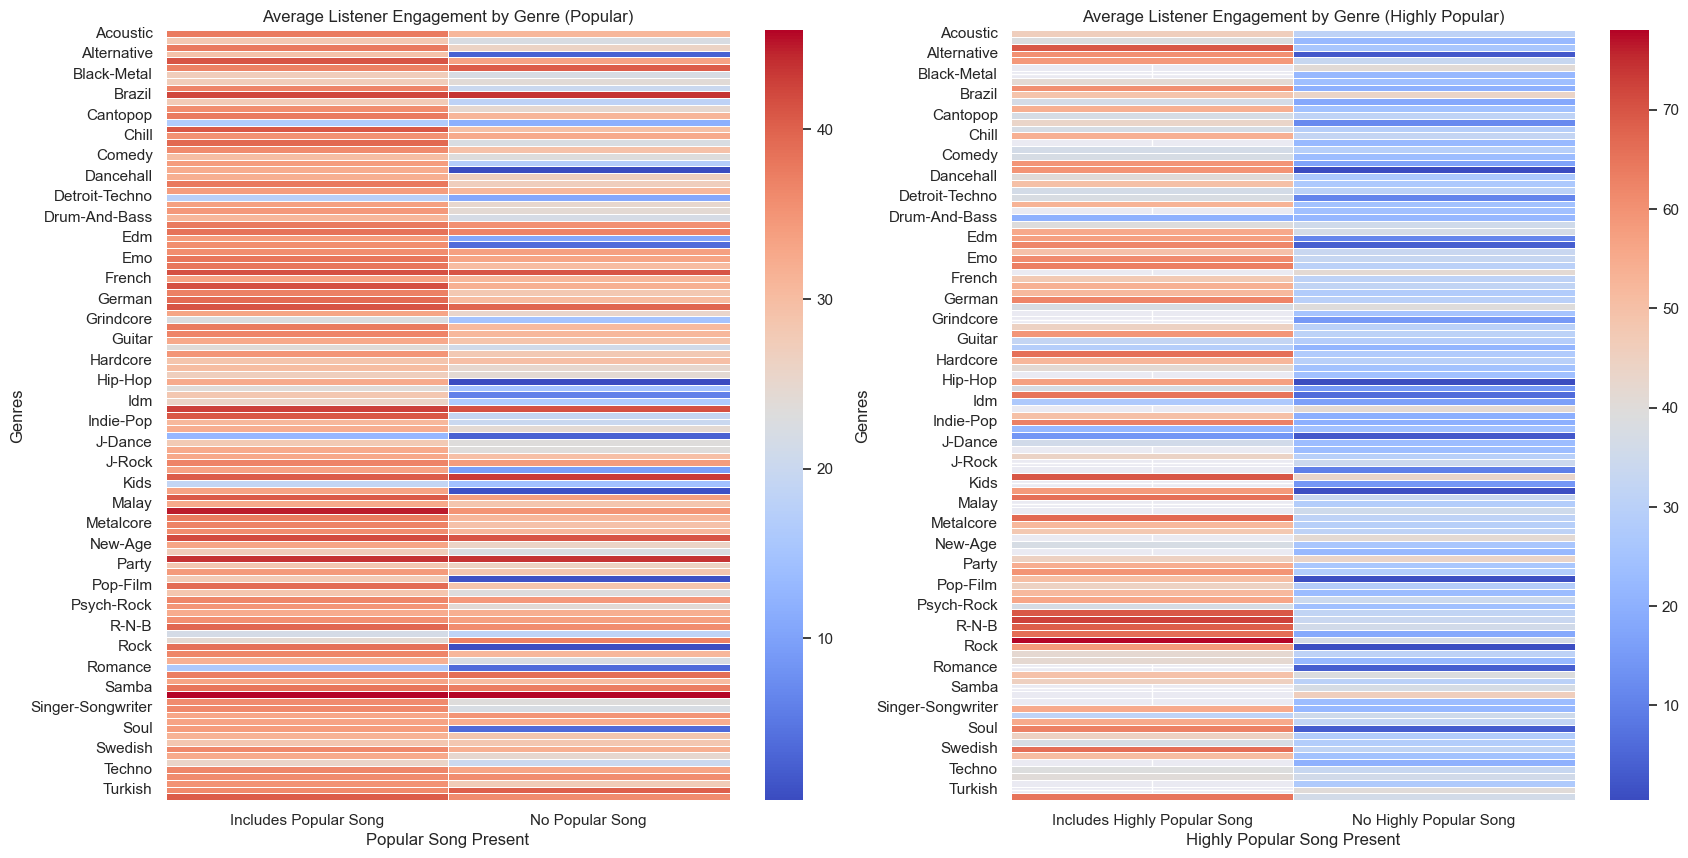

In [50]:
#General view for all genres
heatmap1 = combined_alb.groupby(['track_genre', 'group'])['popularity'].mean().unstack()
heatmap2 = combined_halb.groupby(['track_genre', 'group'])['popularity'].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(20, 10))  # 1 row, 2 columns, shared y-axis

sns.heatmap(heatmap1, ax=axes[0], annot=False, fmt=".2f", cmap="coolwarm", linewidths=0.5)
axes[0].set_title("Average Listener Engagement by Genre (Popular)")
axes[0].set_xlabel("Popular Song Present")
axes[0].set_ylabel("Genres")

# Heatmap 2
sns.heatmap(heatmap2, ax=axes[1], annot=False, fmt=".2f", cmap="coolwarm", linewidths=0.5)
axes[1].set_title("Average Listener Engagement by Genre (Highly Popular)")
axes[1].set_xlabel("Highly Popular Song Present")
axes[1].set_ylabel("Genres") 

In [51]:
#Filtering to the top 10 genres in highly popular song albums since the options are most limited
#Will have a better graph

CH_HP = combined_halb[combined_halb['group'] == 'Includes Highly Popular Song']
top_genres = CH_HP['track_genre'].value_counts().head(10).index

In [52]:
combined_falb = combined_alb[combined_alb['track_genre'].isin(top_genres)]
combined_fhalb = combined_halb[combined_halb['track_genre'].isin(top_genres)]

Text(1062.7045454545453, 0.5, 'Genres')

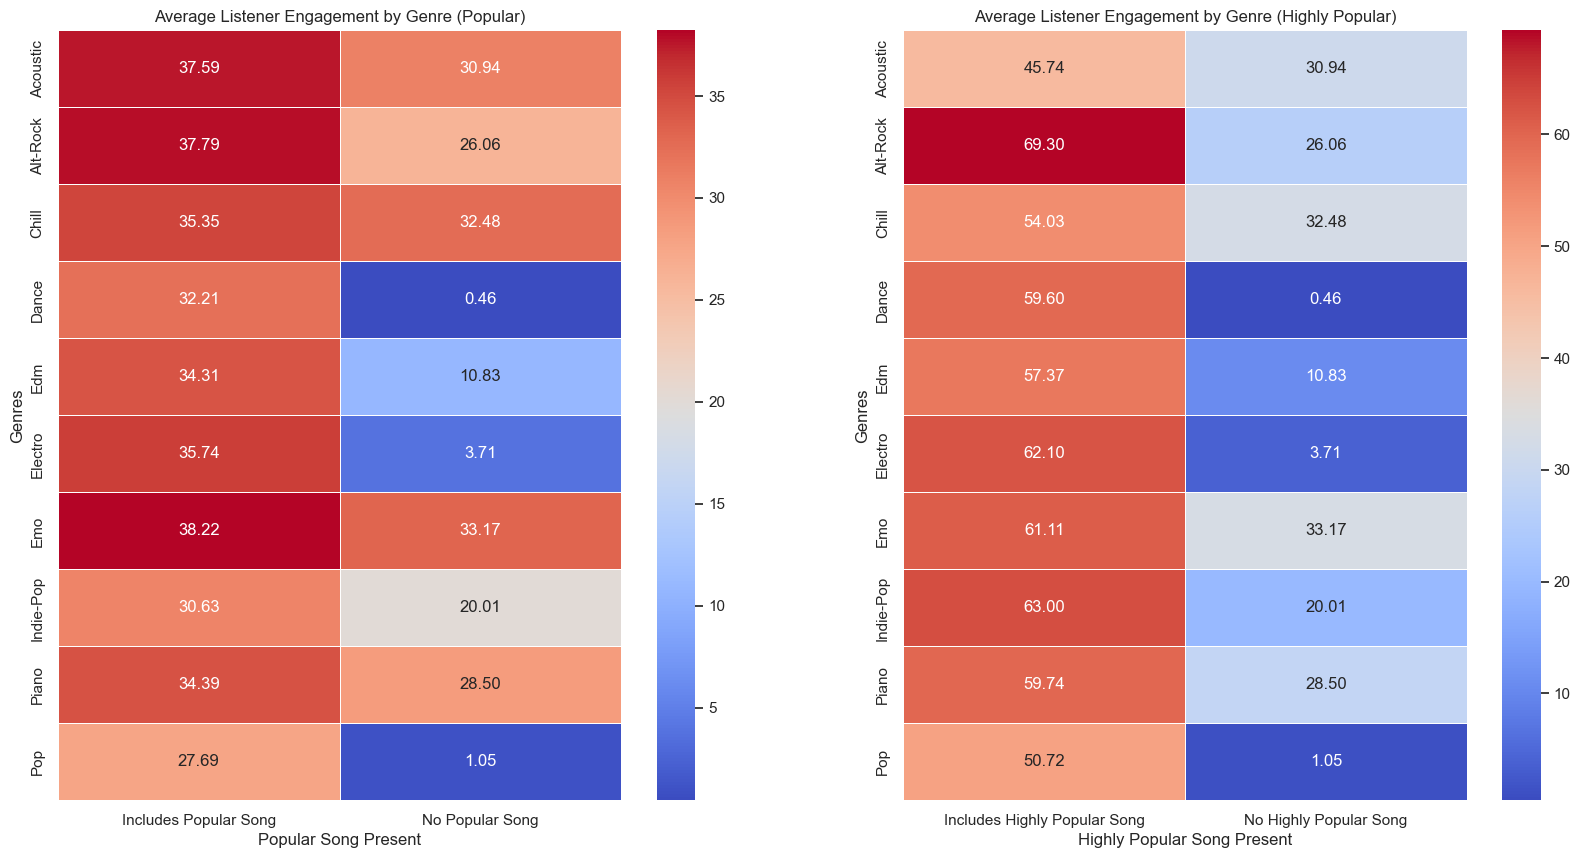

In [53]:
#General view for all genres
heatmap1 = combined_falb.groupby(['track_genre', 'group'])['popularity'].mean().unstack()
heatmap2 = combined_fhalb.groupby(['track_genre', 'group'])['popularity'].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(20, 10))  # 1 row, 2 columns, shared y-axis

sns.heatmap(heatmap1, ax=axes[0], annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
axes[0].set_title("Average Listener Engagement by Genre (Popular)")
axes[0].set_xlabel("Popular Song Present")
axes[0].set_ylabel("Genres")

# Heatmap 2
sns.heatmap(heatmap2, ax=axes[1], annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
axes[1].set_title("Average Listener Engagement by Genre (Highly Popular)")
axes[1].set_xlabel("Highly Popular Song Present")
axes[1].set_ylabel("Genres") 

In [54]:
genre_comb = combined_alb.groupby(['track_genre','group'])['popularity'].describe()
genre_comb.head(6)

count       mean        std        min  \
track_genre group                                                           
Acoustic    Includes Popular Song  104.0  37.593240  10.074514  11.000000   
            No Popular Song        352.0  30.939823  13.606453   0.000000   
Afrobeat    Includes Popular Song   37.0  28.150989  10.616511  13.538462   
            No Popular Song        453.0  22.304982   8.653977   0.000000   
Alt-Rock    Includes Popular Song   55.0  37.794810   9.784835   0.000000   
            No Popular Song        272.0  26.061015  21.548591   0.000000   

                                         25%        50%      75%   max  
track_genre group                                                       
Acoustic    Includes Popular Song  29.950000  41.000000  46.1250  49.0  
            No Popular Song        26.500000  30.500000  41.2500  49.0  
Afrobeat    Includes Popular Song  19.666667  24.428571  36.1250  49.0  
            No Popular Song        18.000000  20.000000  25.0000  49.0  
Alt-Rock    Includes Popular Song  35.250000  40.090909  44.8125  49.0  
            No Popular Song         0.448611  40.633333  45.0000  49.0

In [55]:
genre_comb = combined_halb.groupby(['track_genre','group'])['popularity'].describe()
genre_comb.head(6)

count       mean        std  \
track_genre group                                                       
Acoustic    Includes Highly Popular Song   11.0  45.741142  13.332570   
            No Highly Popular Song        352.0  30.939823  13.606453   
Afrobeat    Includes Highly Popular Song    3.0  38.677778  10.288739   
            No Highly Popular Song        453.0  22.304982   8.653977   
Alt-Rock    Includes Highly Popular Song   18.0  69.298232   6.867621   
            No Highly Popular Song        272.0  26.061015  21.548591   

                                                min        25%        50%  \
track_genre group                                                           
Acoustic    Includes Highly Popular Song  23.750000  37.384615  48.000000   
            No Highly Popular Song         0.000000  26.500000  30.500000   
Afrobeat    Includes Highly Popular Song  26.800000  35.600000  44.400000   
            No Highly Popular Song         0.000000  18.000000  20.000000   
Alt-Rock    Includes Highly Popular Song  55.666667  64.446970  71.400000   
            No Highly Popular Song         0.000000   0.448611  40.633333   

                                                75%        max  
track_genre group                                               
Acoustic    Includes Highly Popular Song  52.750000  72.333333  
            No Highly Popular Song        41.250000  49.000000  
Afrobeat    Includes Highly Popular Song  44.616667  44.833333  
            No Highly Popular Song        25.000000  49.000000  
Alt-Rock    Includes Highly Popular Song  73.000000  79.000000  
            No Highly Popular Song        45.000000  49.000000

**OBSERVATIONS**
- For each genre, albums that have a highly popular song have a higher mean. This means that they have a higher average listener engagement than albums without highly popular songs. 

**Further Analysis**
- P-Tests, Linear Regression

**T-Test**
- The null Hypothesis refers to the hypothesis of no change, and the alternative hypothesis in this case will be one-sided, since we only have we consider the threshold for highly popular songs at 80+.

- Null Hypothesis (Ho = μo) = There is no difference in the average listener engagement in songs for albums with highly popular songs, for each genre
- Alternative Hypothesis (Hn: μ > μo) = The albums with highly popular songs have a higher average listening engagement, for each genre.

In [59]:
results = []

for genre, data in combined_halb.groupby('track_genre'):
    with_hp = data[data['group'].str.contains('Includes')]['popularity']
    without_hp = data[data['group'].str.contains('No')]['popularity']

    with_hp = with_hp.dropna()
    without_hp = without_hp.dropna()
    
    if len(with_hp) > 1 and len(without_hp) > 1:
        t_stat, p_value = scipy.stats.ttest_ind(with_hp, without_hp, alternative='greater')
        results.append({
            'Genre': genre,
            't-statistic': t_stat,
            'p-value': p_value,
            'Average Engagement (With HP)': with_hp.mean(),
            'Average Engagement (Without HP)': without_hp.mean(),
            'Significant': p_value < 0.05  # True if significant
        })

results_df = pd.DataFrame(results)
results_df

,Genre,t-statistic,p-value,Average Engagement (With HP),Average Engagement (Without HP),Significant
0,Acoustic,3.554755,2.143205e-04,45.741142,30.939823,True
1,Afrobeat,3.263166,5.924518e-04,38.677778,22.304982,True
2,Alt-Rock,8.472137,6.291256e-16,69.298232,26.061015,True
3,Alternative,16.697083,1.304702e-35,60.185096,2.650227,True
4,Ambient,3.997599,4.429508e-05,58.842593,33.305767,True
...,...,...,...,...,...,...
60,Study,1.291472,9.850276e-02,37.666667,28.364635,False
61,Swedish,3.594620,1.823041e-04,66.100000,31.850863,True
62,Synth-Pop,4.112742,2.424242e-05,50.828947,24.903388,True
63,Techno,0.892666,1.864671e-01,39.131579,33.223270,False


In [60]:
resultss = results_df[results_df['Significant']== False]
resultss = resultss.dropna(subset=['t-statistic', 'p-value'])

In [61]:
odd_genres = resultss['Genre'].unique()
odd_genres

array(['Brazil', 'Deep-House', 'Drum-And-Bass', 'Dub', 'Guitar', 'Idm',
       'Ska', 'Study', 'Techno', 'Trance'], dtype=object)

In [62]:
checker = combined_halb[combined_halb['track_genre'].isin(resultss['Genre'])]
grouped_counts = checker.groupby(['track_genre', 'group']).size().reset_index(name='count')

grouped_counts.head()

,track_genre,group,count
0,Brazil,Includes Highly Popular Song,3
1,Brazil,No Highly Popular Song,567
2,Deep-House,Includes Highly Popular Song,6
3,Deep-House,No Highly Popular Song,300
4,Drum-And-Bass,Includes Highly Popular Song,2


**Observations** 

For rows with 'True' in the significant column, their p-values are less than 5%. This demonstrates that the null hypothesis can be rejected and that the difference between the popularity values is important.

For rows with 'False' in the significant column, their p-values are more than 5%. This does not fit with our hypothesis, so we looked further into the data. We notice from the table above that these genres had an uneven number of data entries considered for 'no highly popular song' and 'included highly popular song'. Since many more values were included in the 'no highly popular songs' this was able to increase the average and skew the p-value. Due to this inaccuracy, we can overlook these genres until we are given more data to redo analysis.

In other words, it is statically supported that albums with highly popular songs have a higher average listener engagement compared to albums without highly popular songs. This is also supported by each genre in the dataset (for genres that had an adequate amount of data available). 


**Second SubQuestion**

We want to observe whether there is a relationship between the popularity of a 'duplicate' single song to the popularity of the song in the album.

Typically, we would assume that if a single is popular, the track in an album would also be popular, thus there should positive correlation between the popularities. 

In [66]:
#From cleaning, we have this data frame:
true_duplicates.head()

,track_id_singles,artists,album_name_singles,track_name,popularity_singles,track_id_album,album_name_album,popularity_album
0,2X5AFygz5SDYlXagyPw8kX,Zack Tabudlo,Binibini,Binibini,67,55RMhrPQYA6vLu5YMgXxFD,Episode,65
1,0zANeX4R6uWb82gCQAguOD,Zack Tabudlo,Habang Buhay,Habang Buhay,69,63bmIgH9sS6sX5Sc7MetGq,Episode,69
2,7JuocCvYUBbC0X1bZj6guM,Frank Turner,Miranda,Miranda,25,1k1jxdrfofuDZmAuLtyq6m,Fthc (Deluxe),26
3,33j8pvz67cQFfKX6PshhXH,Juanafé;La Flor Del Recuerdo,Mi Último Fracaso,Mi Último Fracaso,23,3rllhj4WKYq3DG35DhCpRP,Parrilladas Vargas (Vol. Ii),18
4,0uBdQzKghx88d2Lp8SLFKJ,The 1975,I'm In Love With You,I'm In Love With You,78,12g9IeQzX7xECLNxz8dpb5,Being Funny In A Foreign Language,71


In [67]:
#Correlation between the columns 
correlation = true_duplicates['popularity_singles'].corr(true_duplicates['popularity_album'])
print(f'The correlation between popularity of the single to the popularity of the song in an album is {correlation}')

The correlation between popularity of the single to the popularity of the song in an album is -0.2435865290767139


The correlation is weak, and it is negative, we should continue looking into the relationship. I will observe the relationship in a scatterplot. There may be a different relationship (not linear) that is not captured with the correlation coefficient. 

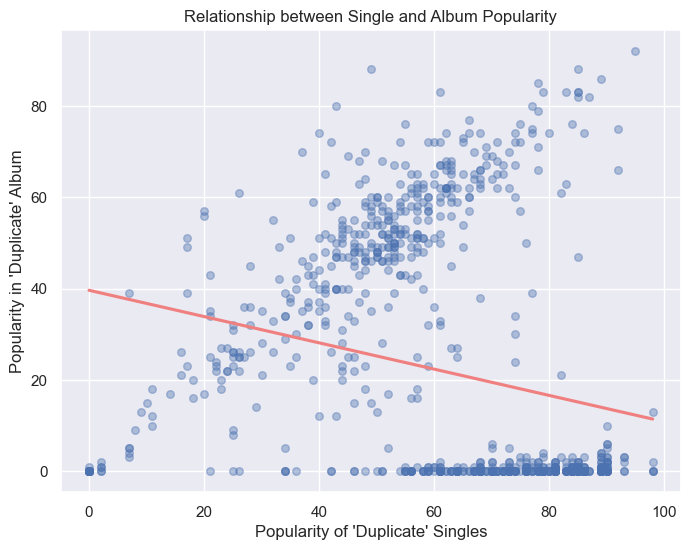

In [69]:
plt.figure(figsize=(8, 6))
sns.regplot(
    x='popularity_singles', 
    y='popularity_album', 
    data=true_duplicates, 
    scatter_kws={'alpha': 0.4, 's': 30}, 
    line_kws= {'color': 'lightcoral', 'linestyle': '-'},
    ci=None
)
plt.title('Relationship between Single and Album Popularity')
plt.xlabel("Popularity of 'Duplicate' Singles")
plt.ylabel("Popularity in 'Duplicate' Album")
plt.grid(True)
plt.show()

From the scatterplot, we can observe that there is a relationship between single and album popularity from the upward trend in the graph. However, there is a dominating group of points in the bottom right. These points indicate tracks that have a high popularity and a single, but very low (close to 0) popularity in albums.

These are odd cases, we will observe them further.

In [71]:
#observing tracks that have a high single popularity but low album popularity
lpa_hsp = true_duplicates[(true_duplicates['popularity_singles'] > 50) & (true_duplicates['popularity_album'] < 10)]
unique_albums = lpa_hsp['album_name_album'].unique()
list(unique_albums[:10])

['Baddest Of Them All',
 'Back To School!',
 "It's You - Fresh Hits",
 'Us Pop 20S',
 "I'm Blue - Hits Of 2022",
 'Beautiful Trending Hits 2022',
 'Running Songs',
 'Hit After Hit',
 'Hits Hits Hits',
 'New Pop Icons']

Once we filtered the dataset to the tracks that had the odd trend (low album popularity but high single popularity), we can observe that many of the 'albums' are playlists. The 'albums' are not specifically made by the artist, but instead, playlists made by Spotify or random Spotify Users. 

Since they are playlists, it is clear why they do not have high popularity since individuals typically listen to tracks from their own created playlists or straight from the artist's page. In addition, some playlists are very niche/specific, such as 'Halloween Party Canzoni Per Bambini 2022', or 'Ballermann Party Hits Megamix 2022.2'. These playlists, although they are public, will be difficult to discover as you need to search specific keywords. 

I will be excluding all of these tracks since they are not truly the tracks we are interested in. We are specifically looking into albums that were posted by the artist rather than random playlists.

In [73]:
#new analysis
lpa_hsp = true_duplicates[~true_duplicates['album_name_album'].isin(unique_albums)]
#Correlation between the columns 
correlation2 = lpa_hsp['popularity_singles'].corr(lpa_hsp['popularity_album'])
print(f'The correlation between popularity of the single to the popularity of the song in an album is {correlation2}')

The correlation between popularity of the single to the popularity of the song in an album is 0.7876977558662176


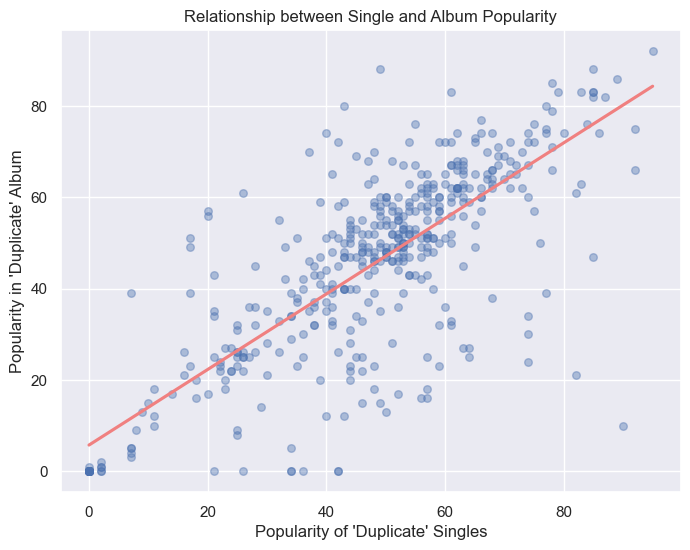

In [74]:
plt.figure(figsize=(8, 6))
sns.regplot(
    x='popularity_singles', 
    y='popularity_album', 
    data=lpa_hsp, 
    scatter_kws={'alpha': 0.4, 's': 30}, 
    line_kws= {'color': 'lightcoral', 'linestyle': '-'},
    ci=None
)
plt.title('Relationship between Single and Album Popularity')
plt.xlabel("Popularity of 'Duplicate' Singles")
plt.ylabel("Popularity in 'Duplicate' Album")
plt.grid(True)
plt.show()

**OBSERVATIONS**

From the plot and the correlation coefficient (0.7876977558662176), we can observe that popular 'duplicate' singles and popular 'duplicate' albums have a positive correlation. In other words, when a track is popular when it is posted as a single, it will also be popular in an album. As long as the albums are well-known and easily discoverable, rather than being put in random playlists.

**Further Analysis**
- Linear Regression

Text(37.53125, 0.5, "Popularity of 'Duplicate' Albums")

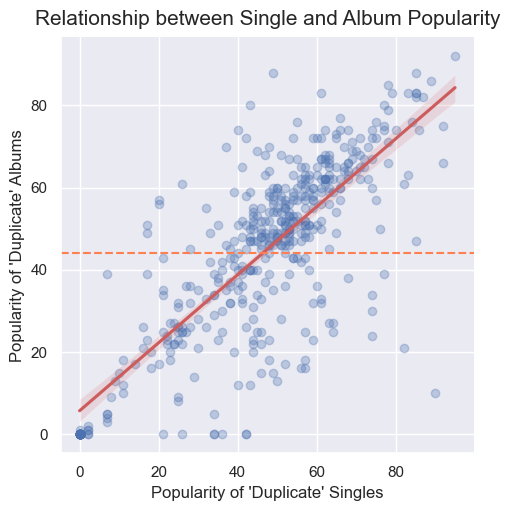

In [77]:
sns.lmplot(x = 'popularity_singles', y = 'popularity_album', data = lpa_hsp, scatter_kws = {'color': 'b', 'alpha': 0.3}, 
           line_kws={'color': 'indianred'})
plt.title("Relationship between Single and Album Popularity", fontsize=15, verticalalignment='bottom')
plt.xlabel("Popularity of 'Duplicate' Singles")
plt.axhline(lpa_hsp['popularity_album'].mean(), ls='--',color = 'coral')
plt.ylabel("Popularity of 'Duplicate' Albums")

In [78]:
model1 = 'popularity_album~popularity_singles'
lm1 = ols(formula = model1, data = lpa_hsp).fit()
print(lm1.summary())

                            OLS Regression Results                            
Dep. Variable:       popularity_album   R-squared:                       0.620
Model:                            OLS   Adj. R-squared:                  0.620
Method:                 Least Squares   F-statistic:                     738.9
Date:                Fri, 06 Dec 2024   Prob (F-statistic):           3.87e-97
Time:                        23:11:46   Log-Likelihood:                -1829.9
No. Observations:                 454   AIC:                             3664.
Df Residuals:                     452   BIC:                             3672.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              5.7228      1

<Axes: xlabel='popularity_album', ylabel='Residuals'>

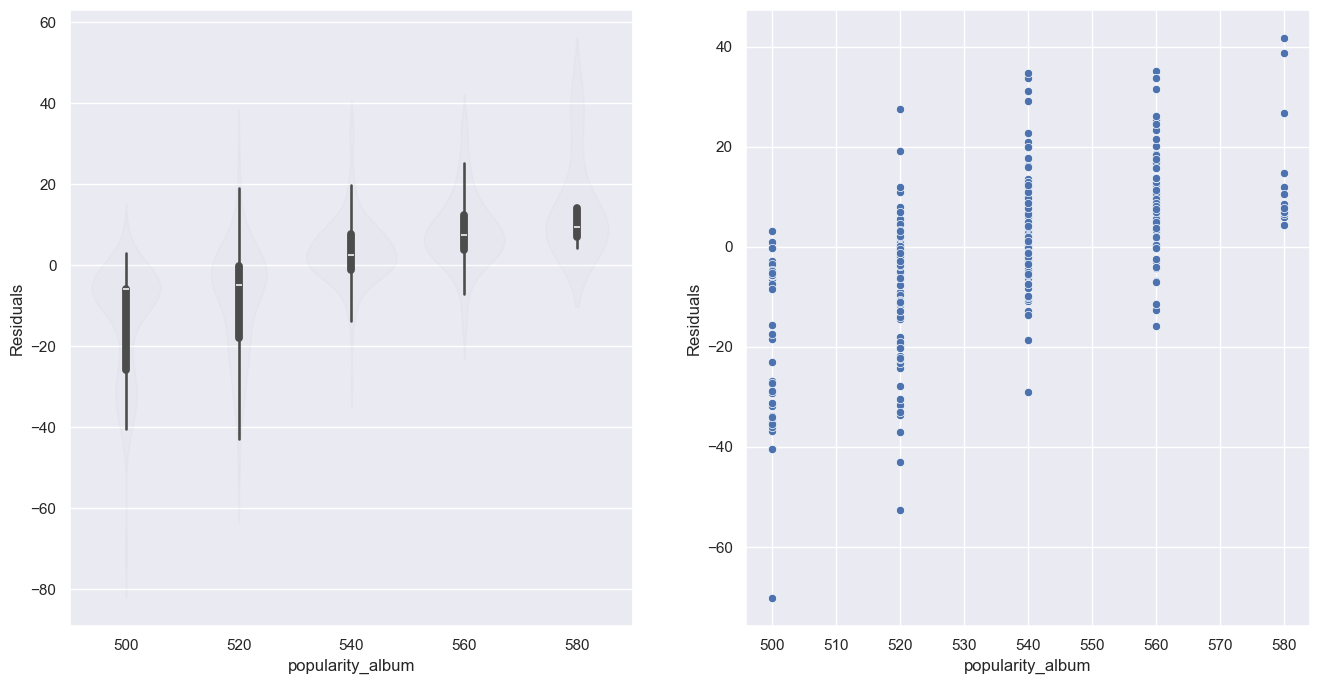

In [79]:
data_clean=lpa_hsp.copy()
bins = np.array([0, 20, 40, 60, 80, 100])
data_clean['popularity_album']=bins[np.digitize(data_clean['popularity_album'], bins)-1]+500
data_clean['Residuals']=lm1.resid.values

fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(16,8))

sns.violinplot(x='popularity_album', y='Residuals',data=data_clean,
               ax=ax[0],alpha=0.02
               )
sns.scatterplot(x='popularity_album',y='Residuals',data=data_clean,ax=ax[1])

In [80]:
#Checking residuals
res = lpa_hsp['popularity_album'] - lm1.fittedvalues
res[0:5]

0    3.843727
1    6.188997
2   -0.406956
3   -6.752227
4    0.742715
dtype: float64

In [81]:
## Checking residuals- if they match
lm1.resid[0:5]

0    3.843727
1    6.188997
2   -0.406956
3   -6.752227
4    0.742715
dtype: float64

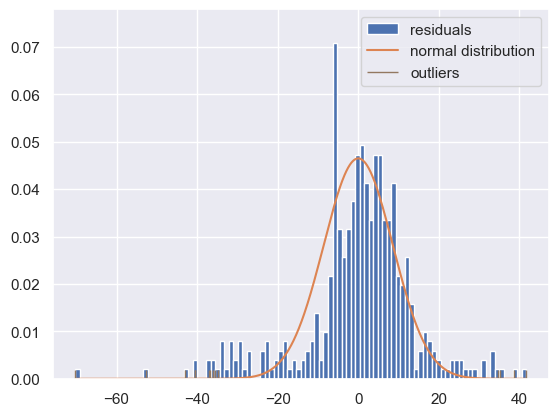

In [82]:
plt.hist(lm1.resid, 
    density=True,     # the histogram integrates to 1 
                      # (so it can be compared to the normal distribution)
    bins=100,         #  draw a histogram with 100 bins of equal width
    label="residuals" # label for legend
    )
# now plot the normal distribution for comparison
xx = np.linspace(lm1.resid.min(), lm1.resid.max(), num=1000)
mad_val=np.median(np.absolute(lm1.resid))
plt.plot(xx, scipy.stats.norm.pdf(xx, loc=0.0, scale=1.5*mad_val),
    label="normal distribution")
outliers = np.abs(lm1.resid)>6*mad_val
sns.rugplot(lm1.resid[outliers],
            color="C5", # otherwise the rugplot has the same color as the histogram
            label="outliers")
plt.legend(loc="upper right");

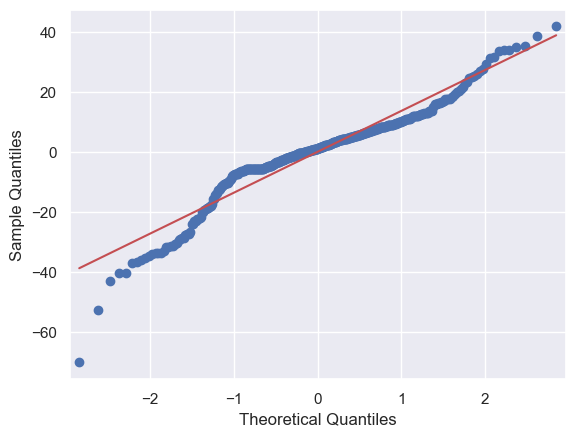

In [83]:
sm.qqplot(lm1.resid, line="s");

In [84]:
lpa_hsp[lpa_hsp["popularity_album"] ==0]
#Notice they are all playlists, remove
lpa_hsp = lpa_hsp[lpa_hsp["popularity_album"] >0]

In [85]:
model1 = 'popularity_album~popularity_singles'
lm1 = ols(formula = model1, data = lpa_hsp).fit()
print(lm1.summary())

                            OLS Regression Results                            
Dep. Variable:       popularity_album   R-squared:                       0.489
Model:                            OLS   Adj. R-squared:                  0.488
Method:                 Least Squares   F-statistic:                     397.3
Date:                Fri, 06 Dec 2024   Prob (F-statistic):           1.69e-62
Time:                        23:11:46   Log-Likelihood:                -1670.3
No. Observations:                 417   AIC:                             3345.
Df Residuals:                     415   BIC:                             3353.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             11.3458      1

In [86]:
lpa_hsp1 = lpa_hsp.copy()
lpa_hsp1["square_popularity_album"] = (lpa_hsp1["popularity_album"] **2)

In [87]:
model_sq = smf.ols(formula = "square_popularity_album ~ popularity_singles", 
                 data = lpa_hsp1).fit()
model_sq.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     square_popularity_album   R-squared:                       0.469
Model:                                 OLS   Adj. R-squared:                  0.468
Method:                      Least Squares   F-statistic:                     367.0
Date:                     Fri, 06 Dec 2024   Prob (F-statistic):           4.55e-59
Time:                             23:11:46   Log-Likelihood:                -3563.7
No. Observations:                      417   AIC:                             7131.
Df Residuals:                          415   BIC:                             7140.
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           -654.3203    182.465     -3.586      0.000   -1012.991    -295.650
popularity_singles    66.1568      3.453     19.158      0.000      59.369      72.945
==============================================================================
Omnibus:                       22.830   Durbin-Watson:                   1.584
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               68.785
Skew:                          -0.055   Prob(JB):                     1.16e-15
Kurtosis:                       4.987   Cond. No.                         158.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

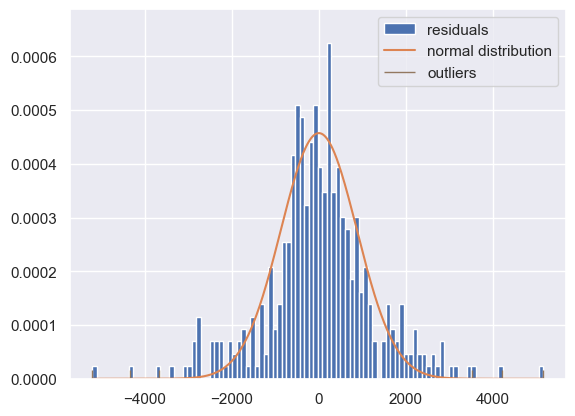

In [88]:
plt.hist(model_sq.resid, 
    density=True,     # the histogram integrates to 1 
                      # (so it can be compared to the normal distribution)
    bins=100,         #  draw a histogram with 100 bins of equal width
    label="residuals" # label for legend
    )
# now plot the normal distribution for comparison
xx = np.linspace(model_sq.resid.min(), model_sq.resid.max(), num=1000)
mad_val=np.median(np.absolute(model_sq.resid))
plt.plot(xx, scipy.stats.norm.pdf(xx, loc=0.0, scale=1.5*mad_val),
    label="normal distribution")
outliers = np.abs(model_sq.resid)>6*mad_val
sns.rugplot(model_sq.resid[outliers],
            color="C5", # otherwise the rugplot has the same color as the histogram
            label="outliers")
plt.legend(loc="upper right");

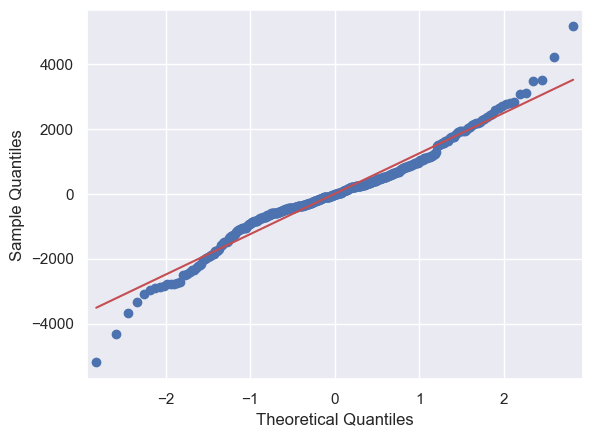

In [89]:
sm.qqplot(model_sq.resid, line="s");

## Second Topic

**Third SubQuestion**

We want to observe whether there is a relationship between the differences in musical attributes with artist collaborations from different genres.

Typically, we would expect that if two artists of different genres collaborate, the musical attributes would be more extreme due to different musical styles. 

In [93]:
#Creating the artist_genre variable 
#takes the mode of all track_genres for a specific artist

artist_genres = df[['artists', 'track_genre']].copy()

#Splits all of the artists to assign each a genre
artist_genres['artists'] = artist_genres['artists'].str.split(';')
artist_genres = artist_genres.explode('artists') #Each artist in own row

#Finds most common genre of tracks they create > that is their primary genre
artist_genre_primary = artist_genres.groupby('artists')['track_genre'].agg(lambda x: x.mode()[0]).reset_index()

In [94]:
#Split all of the artists to different rows to assign genres
df['artists'] = df['artists'].str.split(';')
df = df.explode('artists') 

# Merge the artist genre into the dataframe
df = df.merge(artist_genre_primary, left_on='artists', right_on='artists', how='left', suffixes=('', '_primary'))

In [95]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,track_type,popular_track,num_popular,num_high_popular,num_artist,collab,album_avg_popularity,pop_flag,hpop_flag,track_genre_primary
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,Single,P,1,0,1,S,73.0,True,False,Acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,Album,P,1,0,1,S,55.0,True,False,Acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,Single,P,1,0,2,C,57.0,True,False,Acoustic
3,1iJBSr7s7jYXzM8EGcbK5b,Zayn,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,Single,P,1,0,2,C,57.0,True,False,Dance
4,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,Album,P,1,0,1,S,71.0,True,False,Acoustic


In [96]:
#Filter to only the collaborations
collab_df = df[df['collab'] == 'C']

#Check if the artists on the album are of different genres`
collab_df_genres = df.groupby('track_id')['track_genre_primary'].nunique().reset_index()
collab_df_genres['diff_genre'] = collab_df_genres['track_genre_primary'].apply(lambda x: x > 1)
collab_df = collab_df.merge(collab_df_genres[['track_id', 'diff_genre']], on='track_id', how='left')

In [97]:
collab_df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,popular_track,num_popular,num_high_popular,num_artist,collab,album_avg_popularity,pop_flag,hpop_flag,track_genre_primary,diff_genre
0,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,...,P,1,0,2,C,57.00,True,False,Acoustic,True
1,1iJBSr7s7jYXzM8EGcbK5b,Zayn,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,...,P,1,0,2,C,57.00,True,False,Dance,True
2,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World,Is There Anybody Out There?,Say Something,74,229400,False,0.407,0.147,2,...,P,3,0,2,C,65.00,True,False,Acoustic,False
3,6Vc5wAMmXdKIAM7WUoEb7N,Christina Aguilera,Is There Anybody Out There?,Say Something,74,229400,False,0.407,0.147,2,...,P,3,0,2,C,65.00,True,False,Acoustic,False
4,0IktbUcnAGrvD03AWnz3Q8,Jason Mraz,We Sing. We Dance. We Steal Things.,Lucky,74,189613,False,0.625,0.414,0,...,P,3,1,2,C,74.25,True,True,Acoustic,False


In [98]:
musical_attributes = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 
                      'liveness','valence', 'tempo', 'time_signature', 'duration_ms']
num_attributes = len(musical_attributes)

In [99]:
for attribute in musical_attributes:
    print(f"Statistics for {attribute}:\n")
    attribute_stats = collab_df.groupby('diff_genre')[attribute].agg(['mean', 'std', 'median', 'var'])
    print(attribute_stats)
    print('-'*7)

Statistics for danceability:

                mean       std  median       var
diff_genre                                      
False       0.574268  0.191874   0.600  0.036815
True        0.608817  0.169959   0.635  0.028886
-------
Statistics for energy:

                mean       std  median       var
diff_genre                                      
False       0.594241  0.269640   0.644  0.072706
True        0.661916  0.227893   0.714  0.051935
-------
Statistics for loudness:

                mean       std  median        var
diff_genre                                       
False      -9.198197  6.138898  -7.418  37.686072
True       -7.424651  4.736291  -6.192  22.432449
-------
Statistics for speechiness:

                mean       std  median       var
diff_genre                                      
False       0.096941  0.108283  0.0527  0.011725
True        0.088631  0.083427  0.0539  0.006960
-------
Statistics for acousticness:

                mean       std  median   

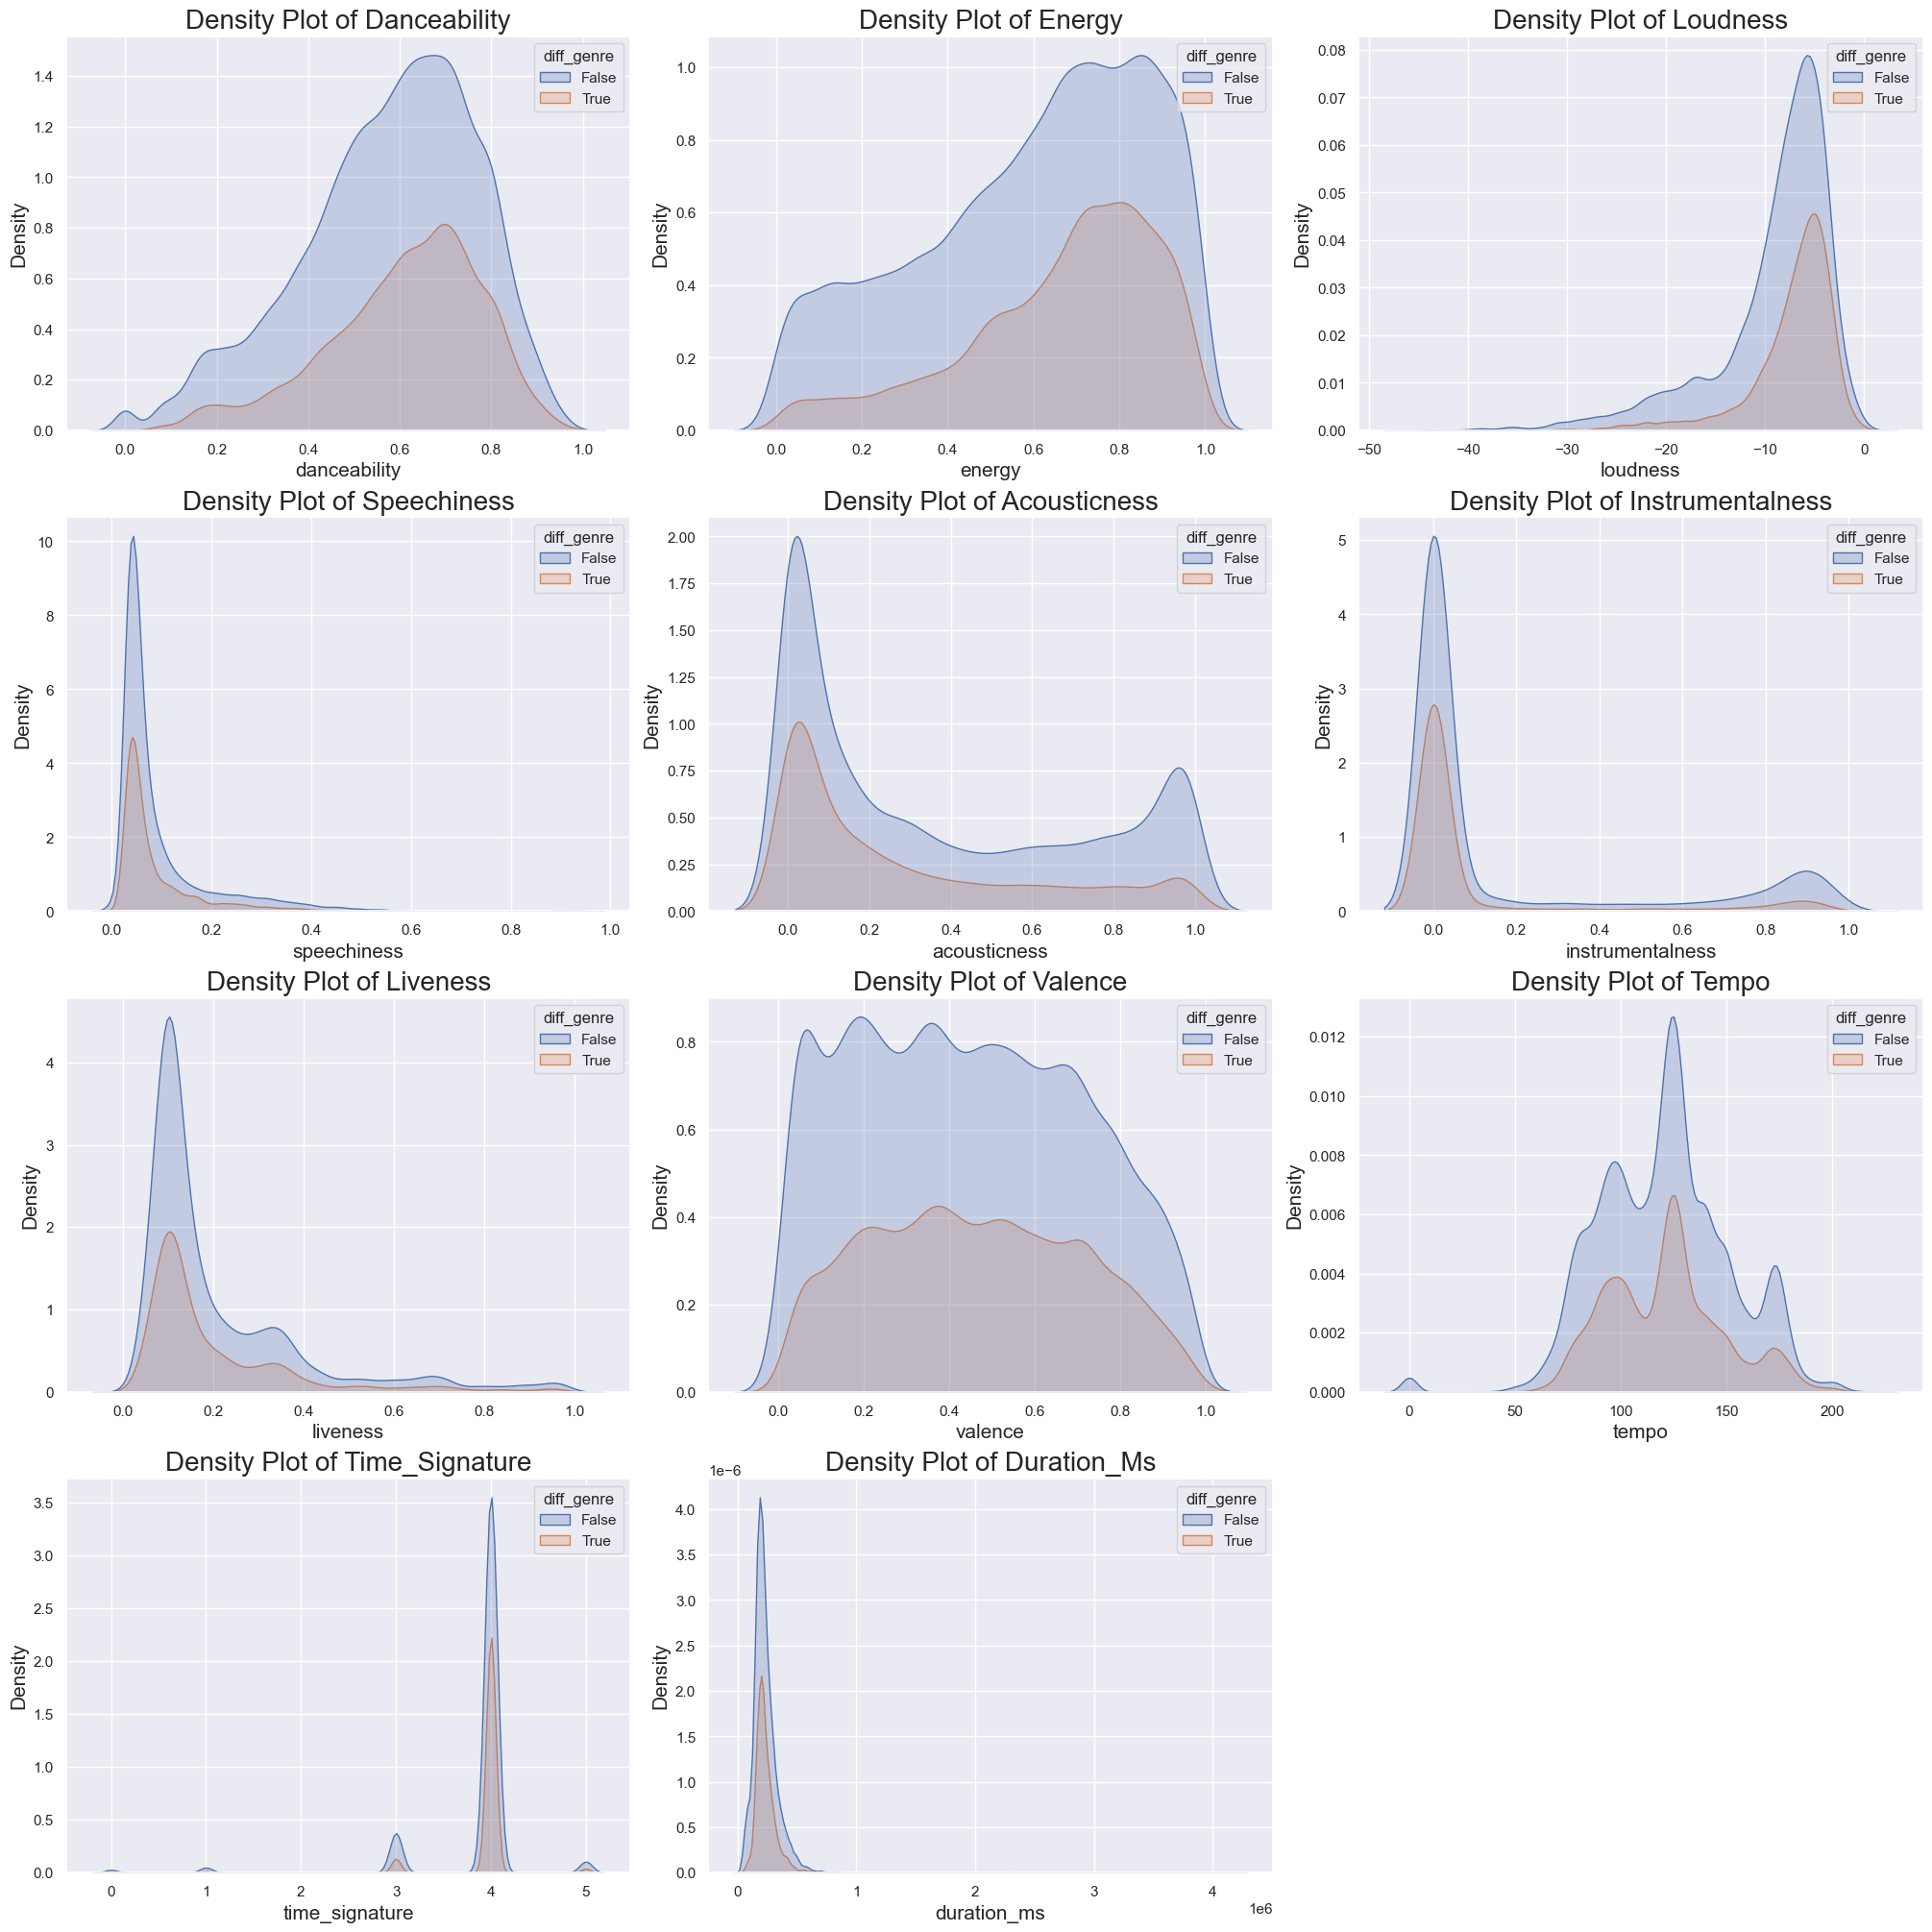

In [100]:
musical_attributes = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 
                      'liveness','valence', 'tempo', 'time_signature', 'duration_ms']

n_rows = 4
n_cols = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 20), constrained_layout=True) 
axes = axes.flatten()  

# Loop through each attribute and its corresponding subplot
for i, attribute in enumerate(musical_attributes):
    ax = axes[i]  # Get the subplot axis
    sns.kdeplot(data=collab_df, x=attribute, hue='diff_genre', fill=True, ax=ax)  # Plot on this axis
    ax.set_title(f'Density Plot of {attribute.title()}', fontsize = 20)
    ax.set_xlabel(attribute, fontsize = 15)
    ax.set_ylabel('Density', fontsize = 15)

# Remove extra subplots
for j in range(len(musical_attributes), len(axes)):
    fig.delaxes(axes[j])

# Display the plots
plt.show()

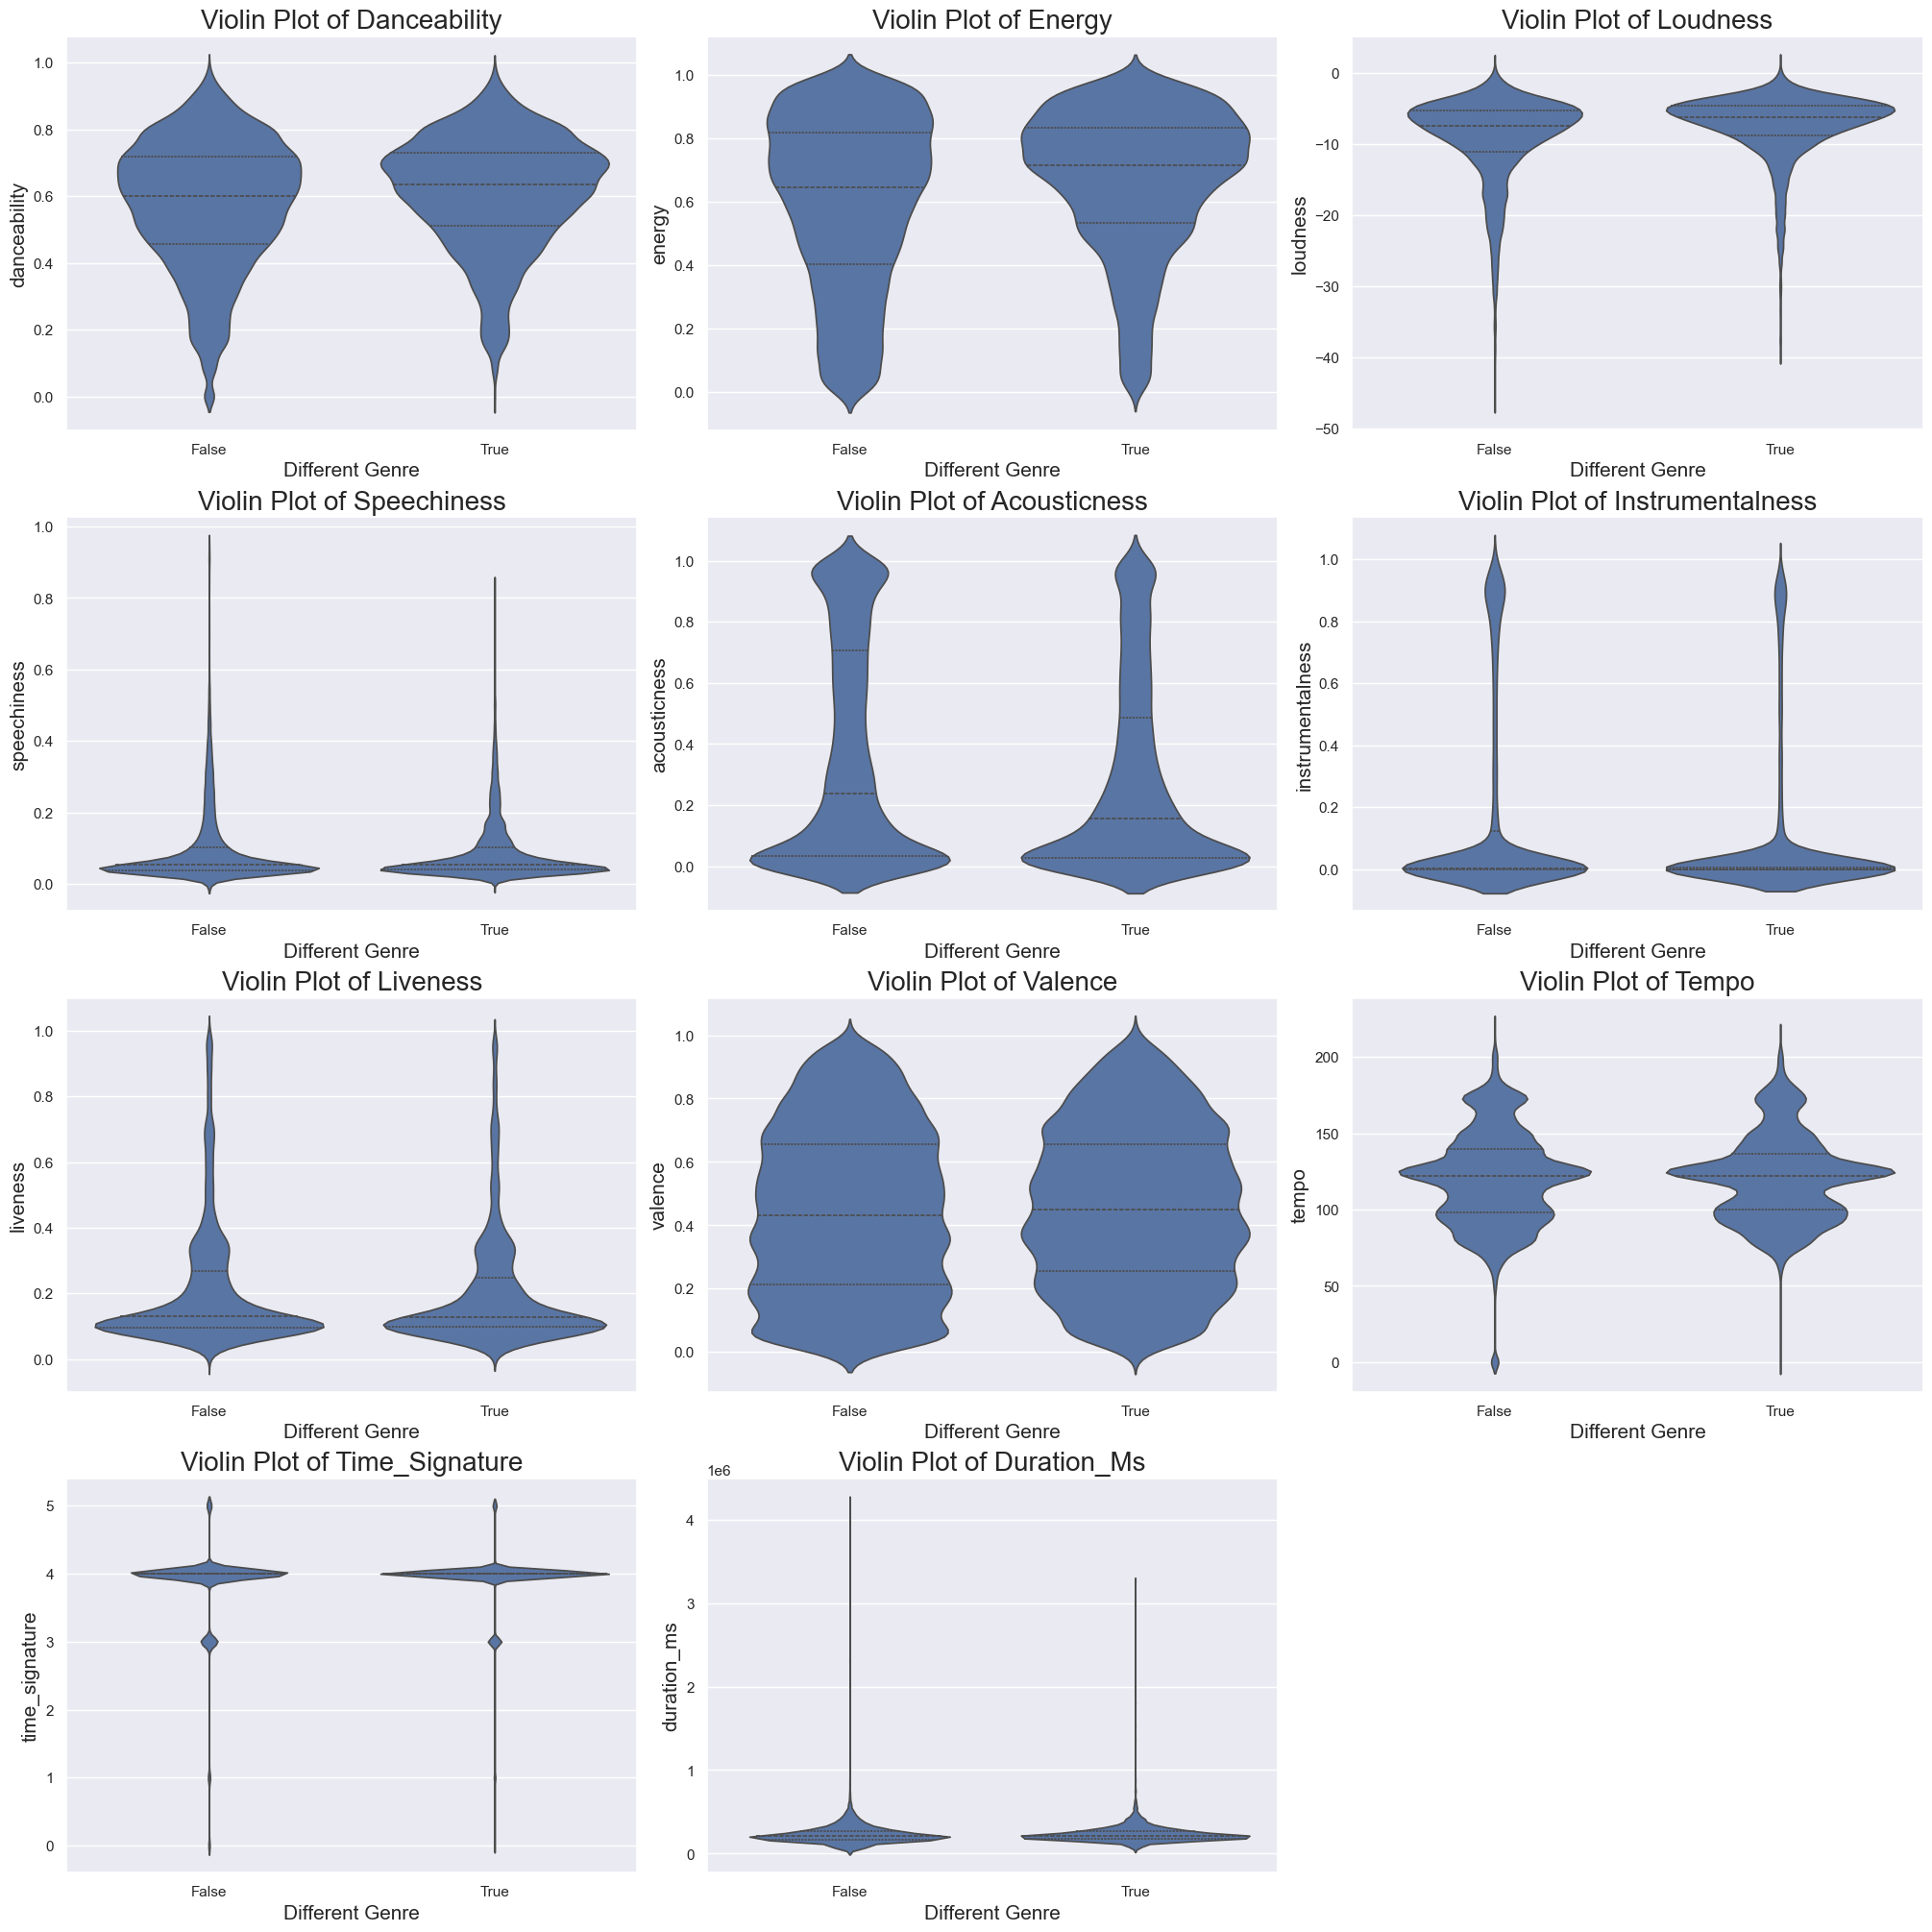

In [101]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 20), constrained_layout=True)
axes = axes.flatten()

for i, attribute in enumerate(musical_attributes):
    ax = axes[i]
    sns.violinplot(data=collab_df, x='diff_genre', y=attribute, ax=ax, inner='quartile')
    ax.set_title(f'Violin Plot of {attribute.title()}', fontsize=20)
    ax.set_xlabel('Different Genre', fontsize=15)
    ax.set_ylabel(attribute, fontsize=15)

# Remove extra subplots
for j in range(len(musical_attributes), len(axes)):
    fig.delaxes(axes[j])

plt.show()

**Observations**


Summary of Key Points to Look For:
Peaks (Location): Indicates the mode/central value.
Spread: How wide or narrow the peak is, indicating variance.
Skewness: Indicates if the distribution is asymmetric.
Kurtosis: Tails of the distribution, showing how extreme values are distributed.
Overlap: How much the distributions share common values.
Tail Behavior: Indicates the presence of extreme values or outliers.
Area under Curve: Represents the probability distribution, but focus on shape.
Outliers: Extreme values that are separated from the main distribution.
Shape: Overall pattern of the distribution (e.g., normal, bimodal).

**Further Analysis**
- P-Tests, Linear Regression